# 05 Categorical Features (E-19 to E-23)

**Data used:** the development set.  
**Questions:** Q12 near-constant and rare categories, Q13 ordinal monotonicity (DOC-02 §4.4).

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import categorical

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = categorical.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-19_categorical_profile',
 'E-19_foundation_year_built',
 'E-20_rare_categories',
 'E-21_category_importance',
 'E-21_price_by_category',
 'E-22_neighborhoods',
 'E-23_ordinal_levels',
 'E-23_ordinal_monotonicity',
 'E-21_price_by_category_1',
 'E-21_price_by_category_2',
 'E-21_price_by_category_3',
 'E-22_neighborhoods',
 'E-23_ordinal_monotonicity']

## E-19 Categorical profile: cardinality, top level and share, levels under 1%.

In [3]:
outputs.tables["E-19_categorical_profile"]

,feature,role,n_levels,top_level,top_share,n_levels_under_1pct
0,Neighborhood,model_input,28,NAmes,0.151282,7
1,Exterior2nd,model_input,17,VinylSd,0.343590,7
2,Exterior1st,model_input,16,VinylSd,0.348718,6
3,MSSubClass,model_input,16,20,0.370513,5
4,SaleType,excluded,10,WD,0.863675,7
5,Condition1,model_input,9,Norm,0.856410,4
6,Condition2,model_input,8,Norm,0.990598,7
7,Functional,model_input,8,Typ,0.931624,4
8,HouseStyle,model_input,8,1Story,0.508974,3
9,BsmtFinType1,model_input,7,Unf,0.297009,0


In [4]:
outputs.tables["E-19_foundation_year_built"]

,Foundation,n,median_year_built
0,PConc,1049,2002.0
1,Wood,4,1991.5
2,CBlock,991,1963.0
3,Slab,41,1956.0
4,BrkTil,246,1922.0
5,Stone,9,1900.0


## E-20 Rare categories (under 1% of development rows).

In [5]:
outputs.tables["E-20_rare_categories"]

,feature,level,count,share_pct
0,BsmtCond,Ex,2,0.085470
1,BsmtCond,Po,4,0.170940
2,BsmtFinType2,GLQ,23,0.982906
3,BsmtQual,Po,2,0.085470
4,Condition1,RRNe,6,0.256410
...,...,...,...,...
99,SaleType,CWD,10,0.427350
100,SaleType,ConLD,22,0.940171
101,Street,Grvl,10,0.427350
102,Utilities,NoSeWa,1,0.042735


## E-21 Log price by category, ranked by eta² (share of log-price variance explained).

In [6]:
outputs.tables["E-21_category_importance"]

,rank,feature,n_levels,eta_squared,median_range
0,1,Neighborhood,28,0.593514,1.295790
1,2,BsmtQual,6,0.488802,1.327387
2,3,ExterQual,4,0.472567,1.405467
3,4,KitchenQual,5,0.445100,1.129858
4,5,GarageFinish,4,0.376595,0.761801
5,6,MSSubClass,16,0.334160,0.849308
6,7,GarageType,7,0.327099,0.847973
7,8,FireplaceQu,6,0.317875,0.927683
8,9,Foundation,6,0.313281,0.688276
9,10,HeatingQC,5,0.254467,1.655356


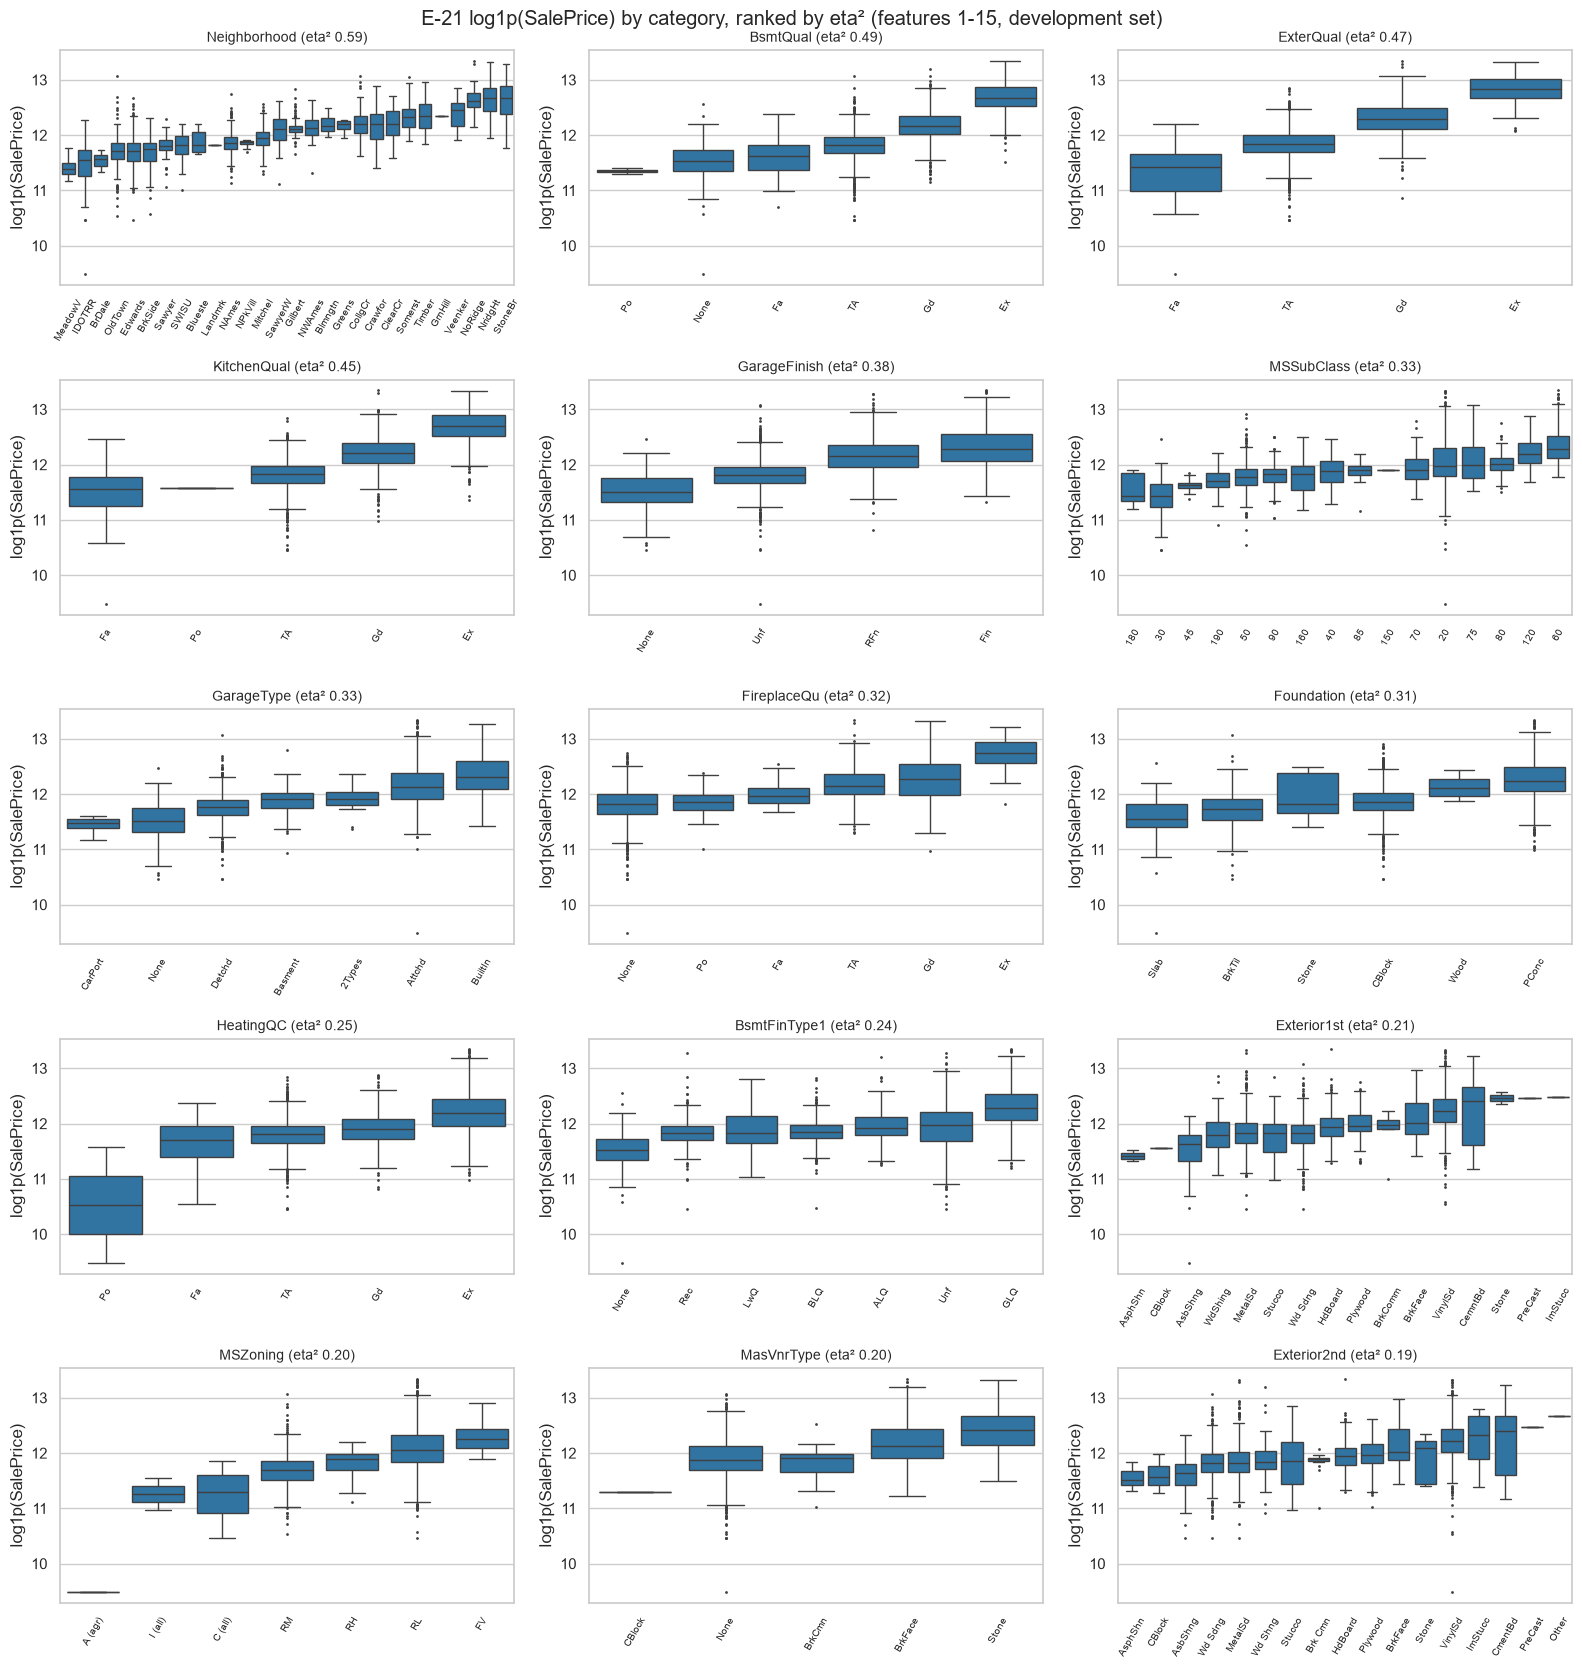

In [7]:
Image(filename=outputs.figures["E-21_price_by_category_1"])

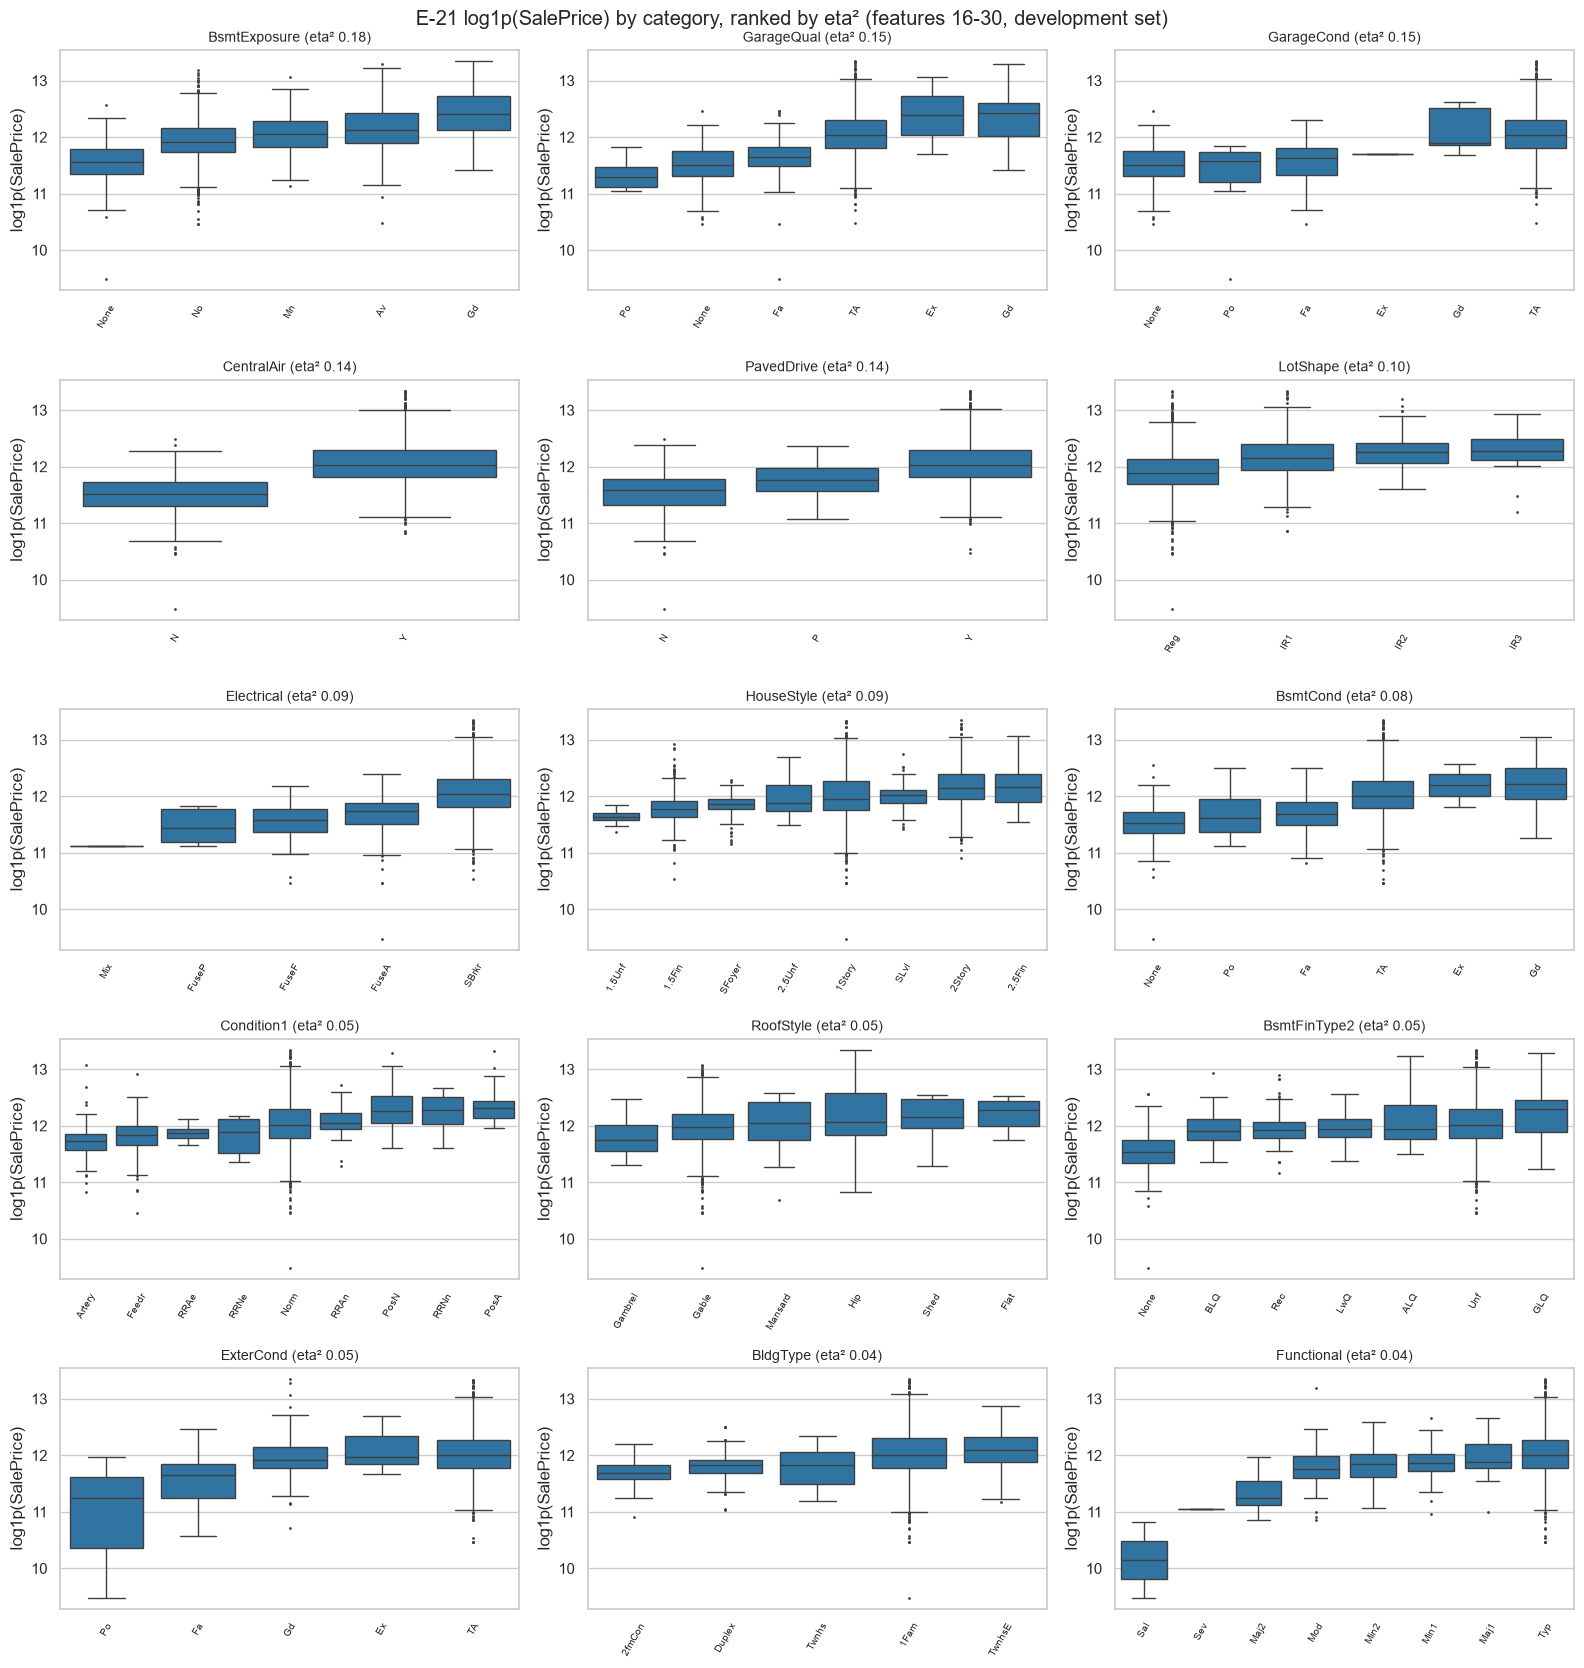

In [8]:
Image(filename=outputs.figures["E-21_price_by_category_2"])

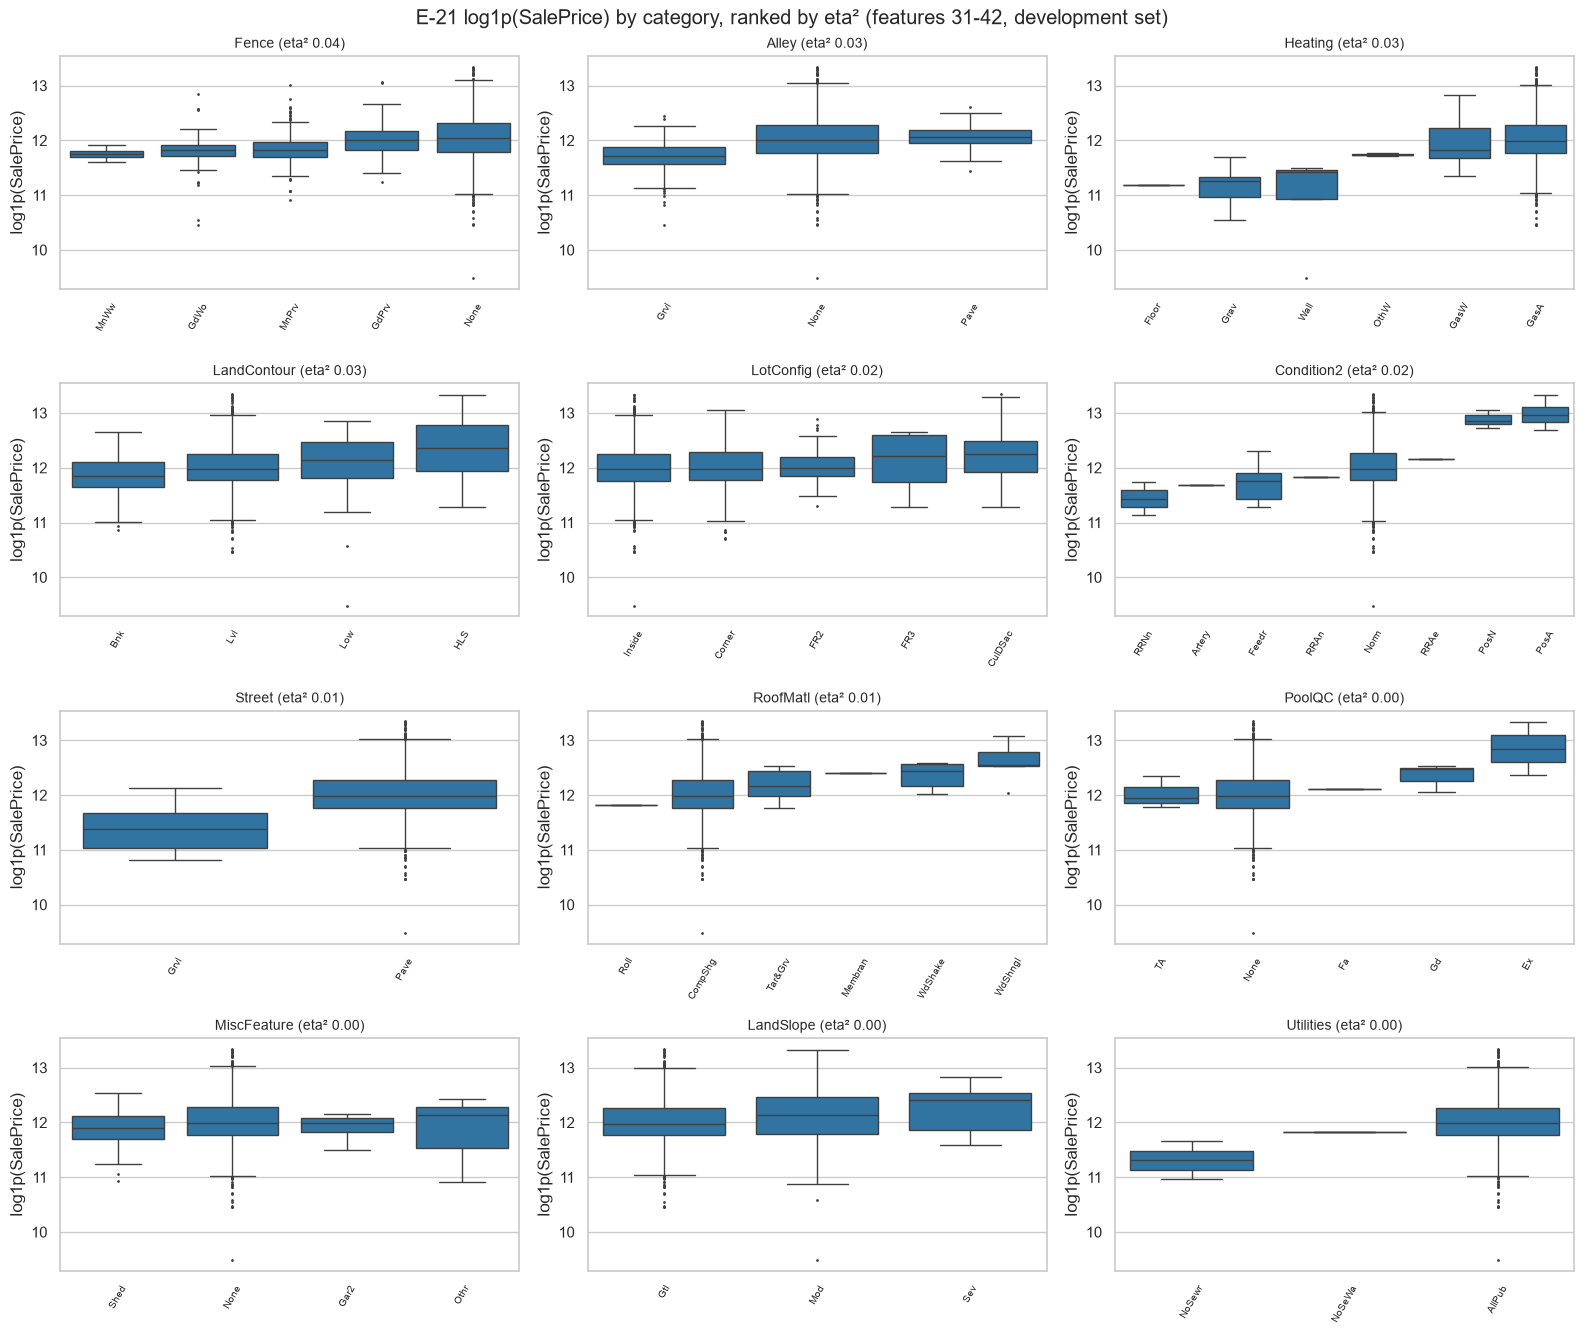

In [9]:
Image(filename=outputs.figures["E-21_price_by_category_3"])

## E-22 Neighborhoods: row count and median log price.

In [10]:
outputs.tables["E-22_neighborhoods"]

,Neighborhood,n,median_log_price
0,MeadowV,29,11.379977
1,IDOTRR,73,11.542494
2,BrDale,24,11.566476
3,OldTown,207,11.711785
4,Edwards,153,11.719948
5,BrkSide,89,11.748005
6,Sawyer,115,11.809327
7,SWISU,37,11.824087
8,Blueste,7,11.827744
9,Landmrk,1,11.827744


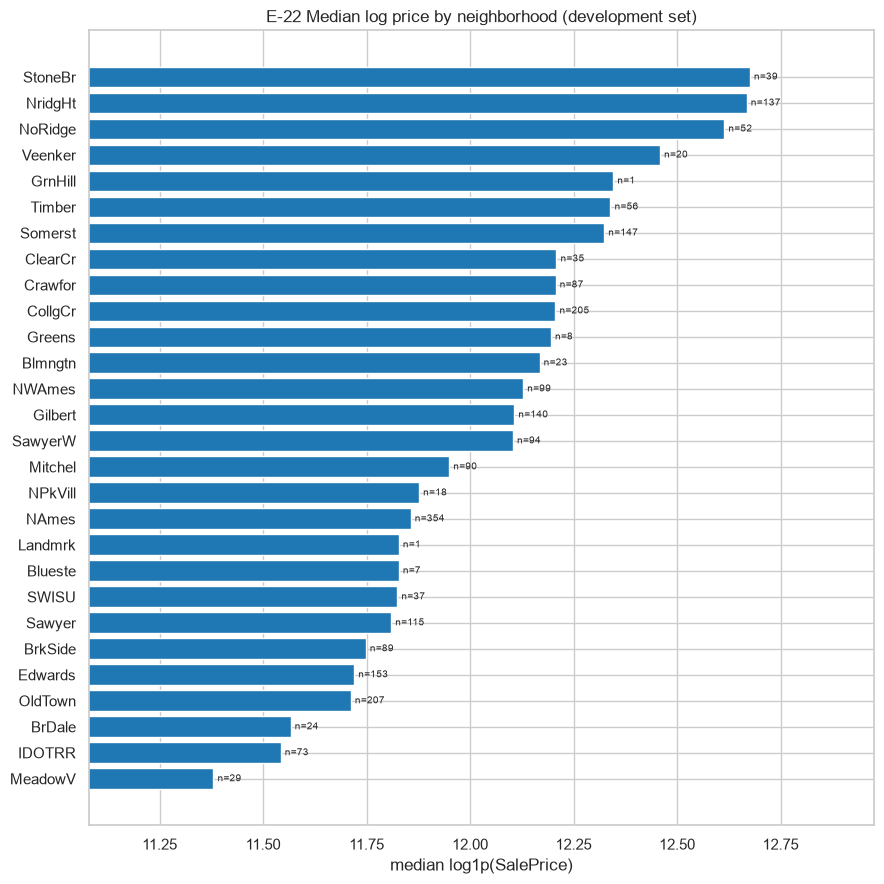

In [11]:
Image(filename=outputs.figures["E-22_neighborhoods"])

## E-23 Ordinal monotonicity of the Po-Ex scales (None first).

In [12]:
outputs.tables["E-23_ordinal_monotonicity"]

,scale,levels_used,assessable,monotonic,median_spread,note
0,ExterQual,Fa|TA|Gd|Ex,True,True,1.405467,median log price rises through every level wit...
1,ExterCond,Fa|TA|Gd,True,False,0.361011,not monotonic across levels with at least 10 rows
2,BsmtQual,None|Fa|TA|Gd|Ex,True,True,1.145304,median log price rises through every level wit...
3,BsmtCond,None|Fa|TA|Gd,True,True,0.684007,median log price rises through every level wit...
4,HeatingQC,Fa|TA|Gd|Ex,True,True,0.482321,median log price rises through every level wit...
5,KitchenQual,Fa|TA|Gd|Ex,True,True,1.129858,median log price rises through every level wit...
6,FireplaceQu,None|Po|Fa|TA|Gd|Ex,True,True,0.927683,median log price rises through every level wit...
7,GarageQual,None|Fa|TA|Gd,True,True,0.904688,median log price rises through every level wit...
8,GarageCond,None|Po|Fa|TA|Gd,True,False,0.525725,not monotonic across levels with at least 10 rows
9,PoolQC,None,False,False,0.000000,not assessable: fewer than two levels with at ...


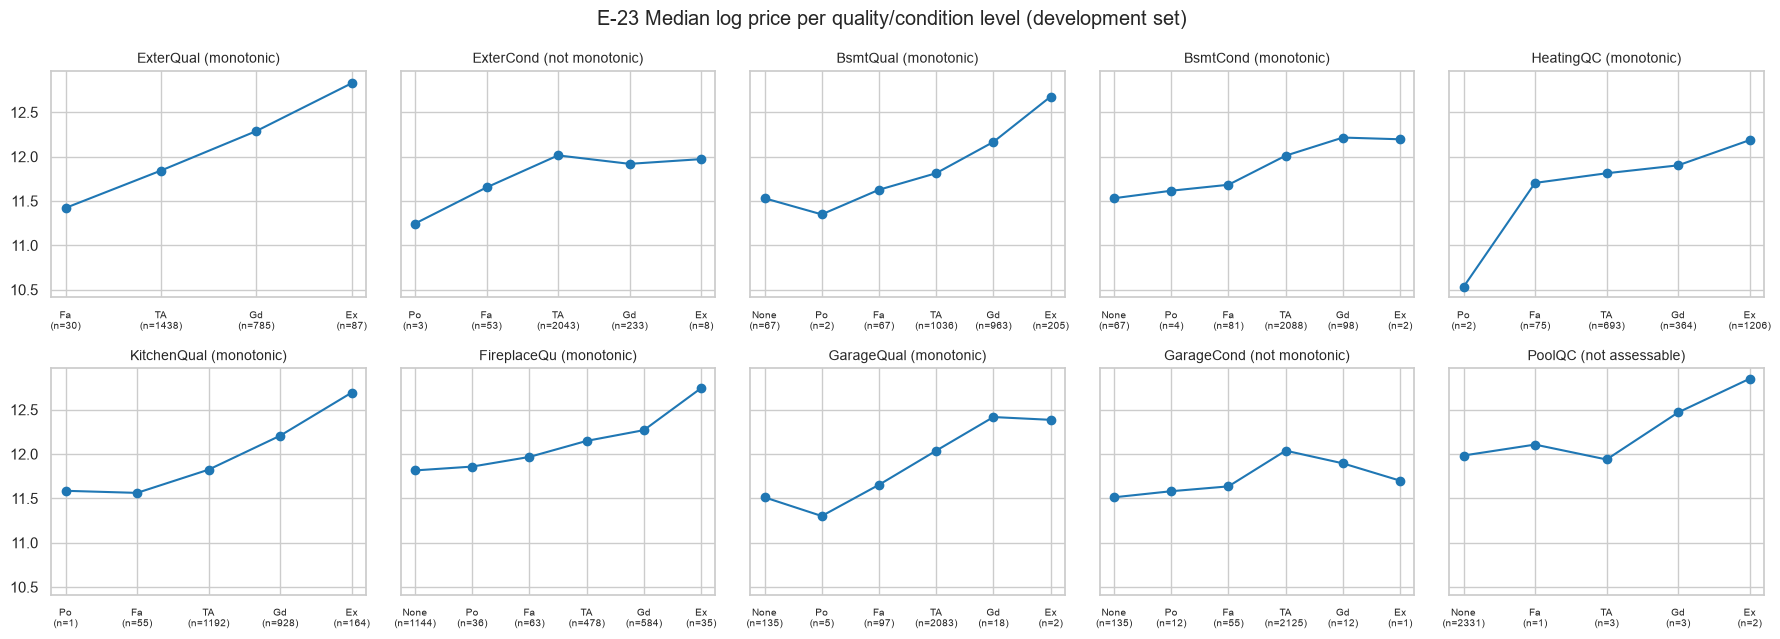

In [13]:
Image(filename=outputs.figures["E-23_ordinal_monotonicity"])